In [1]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Input, Embedding, LSTM, Dense, Dropout
from tensorflow.keras.datasets import imdb
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

import random
import tensorflow as tf
import warnings
warnings.filterwarnings("ignore")

np.random.seed(42)
random.seed(42)
tf.random.set_seed(42)

In [2]:
vocab_size = 10000
max_length = 200

(X_train_full, y_train_full), (X_test, y_test) = imdb.load_data(num_words=vocab_size)

X_train_full, X_val_raw, y_train_full, y_val_raw = train_test_split(
    X_train_full,
    y_train_full,
    test_size=0.2,
    random_state=42,
    stratify=y_train_full,
)

print("Train samples:", len(X_train_full))
print("Validation samples:", len(X_val_raw))
print("Test samples:", len(X_test))

Train samples: 20000
Validation samples: 5000
Test samples: 25000


In [3]:
X_train = pad_sequences(X_train_full, maxlen=max_length)
X_val = pad_sequences(X_val_raw, maxlen=max_length)
X_test = pad_sequences(X_test, maxlen=max_length)

y_train = np.asarray(y_train_full)
y_val = np.asarray(y_val_raw)
y_test = np.asarray(y_test)

word_index = imdb.get_word_index()
reverse_word_index = {value + 3: key for key, value in word_index.items()}
reverse_word_index[0] = "<PAD>"
reverse_word_index[1] = "<START>"
reverse_word_index[2] = "<UNK>"
reverse_word_index[3] = "<UNUSED>"

def decode_review(sequence):
    return " ".join(reverse_word_index.get(i, "?") for i in sequence if i != 0)

In [4]:
model = Sequential([
    Input(shape=(max_length,)),
    Embedding(input_dim=vocab_size, output_dim=128),
    LSTM(64, dropout=0.2, recurrent_dropout=0.2),
    Dense(32, activation="relu"),
    Dropout(0.3),
    Dense(1, activation="sigmoid")
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",
    metrics=["accuracy", tf.keras.metrics.AUC(name="auc")],
)

early_stop = EarlyStopping(monitor="val_loss", patience=2, restore_best_weights=True)
lr_drop = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=1, min_lr=1e-5)

history = model.fit(
    X_train,
    y_train,
    epochs=5,
    batch_size=64,
    validation_data=(X_val, y_val),
    callbacks=[early_stop, lr_drop],
    verbose=1,
)

model.summary()

Epoch 1/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 43s 126ms/step - accuracy: 0.7589 - auc: 0.8438 - loss: 0.4918 - val_accuracy: 0.8306 - val_auc: 0.9179 - val_loss: 0.3924 - learning_rate: 0.0010
Epoch 2/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 41s 131ms/step - accuracy: 0.8504 - auc: 0.9224 - loss: 0.3551 - val_accuracy: 0.8482 - val_auc: 0.9213 - val_loss: 0.3721 - learning_rate: 0.0010
Epoch 3/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 42s 135ms/step - accuracy: 0.8844 - auc: 0.9475 - loss: 0.2916 - val_accuracy: 0.8384 - val_auc: 0.9224 - val_loss: 0.4459 - learning_rate: 0.0010
Epoch 4/5
313/313 ━━━━━━━━━━━━━━━━━━━━ 45s 142ms/step - accuracy: 0.9180 - auc: 0.9703 - loss: 0.2170 - val_accuracy: 0.8544 - val_auc: 0.9232 - val_loss: 0.3980 - learning_rate: 5.0000e-04


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ (None, 200, 128)       │     1,280,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,994,565 (15.24 MB)

 Trainable params: 1,331,521 (5.08 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2,663,044 (10.16 MB)

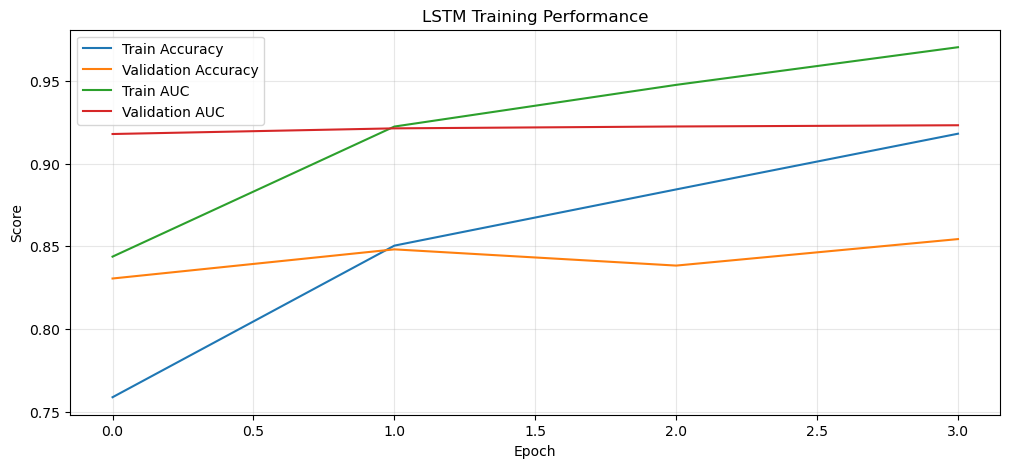

In [5]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.plot(history.history["auc"], label="Train AUC")
plt.plot(history.history["val_auc"], label="Validation AUC")
plt.title("LSTM Training Performance")
plt.xlabel("Epoch")
plt.ylabel("Score")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

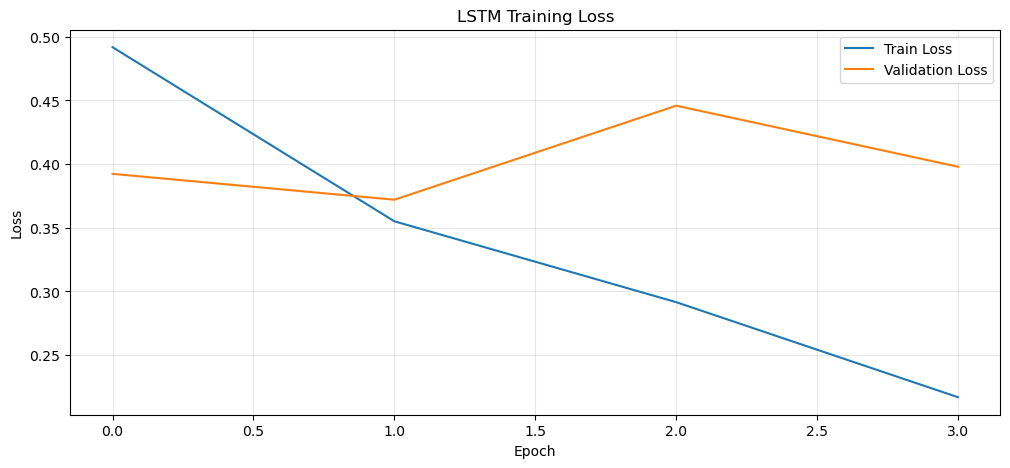

Test Accuracy: 0.8465
Test AUC: 0.9240

Classification Report:
              precision    recall  f1-score   support

    negative       0.82      0.89      0.85     12500
    positive       0.88      0.80      0.84     12500

    accuracy                           0.85     25000
   macro avg       0.85      0.85      0.85     25000
weighted avg       0.85      0.85      0.85     25000



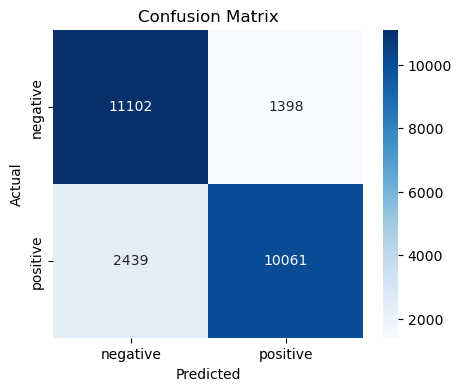

In [6]:
plt.figure(figsize=(12, 5))
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("LSTM Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

test_loss, test_acc, test_auc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")
print(f"Test AUC: {test_auc:.4f}")

test_probs = model.predict(X_test, verbose=0).ravel()
test_preds = (test_probs >= 0.5).astype(int)
print("\nClassification Report:")
print(classification_report(y_test, test_preds, target_names=["negative", "positive"]))

cm = confusion_matrix(y_test, test_preds)
plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["negative", "positive"], yticklabels=["negative", "positive"])
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [7]:
sample_indices = [1, 10, 20]

for idx in sample_indices:
    review_text = decode_review(X_test[idx])
    predicted_label = "positive" if test_preds[idx] == 1 else "negative"
    actual_label = "positive" if y_test[idx] == 1 else "negative"
    print("Review:")
    print(review_text[:500], "...")
    print("Actual:", actual_label)
    print("Predicted:", predicted_label)
    print("-" * 80)

Review:
psychological <UNK> it's very interesting that robert altman directed this considering the style and structure of his other films still the trademark altman audio style is evident here and there i think what really makes this film work is the brilliant performance by sandy dennis it's definitely one of her darker characters but she plays it so perfectly and convincingly that it's scary michael burns does a good job as the mute young man regular altman player michael murphy has a small part the < ...
Actual: positive
Predicted: positive
--------------------------------------------------------------------------------
Review:
of two men <UNK> murders in exchange for getting rid of the two people messing up their lives throw <UNK> from the train is an original and very inventive comedy take on the idea it's a credit to danny <UNK> that he both wrote and starred in this minor comedy gem br br anne <UNK> is the mother who <UNK> the film's title and it's understandable why she gets un